# The DC Motor — Electromechanics of a Copper-Wound Machine

A permanent-magnet DC motor is two coupled first-order systems sharing one shaft:

$$\underbrace{V = R\,i + L\,\frac{di}{dt} + K_e\,\omega}_{\text{electrical loop (back-EMF }K_e\omega)},
\qquad
\underbrace{J\,\frac{d\omega}{dt} = K_t\,i - b\,\omega - \tau_L}_{\text{mechanical (torque vs load)}}.$$

The magnetic field turns current into torque ($\tau=K_t i$, the Lorentz/magnetostatics side); the
spinning rotor turns speed back into a voltage ($K_e\omega$, the Faraday side); and in SI the two
constants are equal, $K_t=K_e$. The windings are **copper**, so they dissipate $i^2R$ — the loss that
sets the motor's efficiency and how hot it runs. Engine: the repo's `dc_motor.py`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from dgs import dc_motor as dm

# a small PMDC motor (SI units), e.g. driving a robot leg joint
V, R, L, Ke, Kt, J, b = 12.0, 1.0, 1e-3, 0.05, 0.05, 1e-4, 1e-5
print(f"no-load speed {dm.no_load_speed(V,R,Ke,Kt,b):.0f} rad/s, "
      f"stall torque {dm.stall_torque(V,R,Kt):.2f} N*m")

no-load speed 239 rad/s, stall torque 0.60 N*m


## §1 The torque-speed curve

Eliminate the time derivatives and the operating points fall on a straight line: maximum torque at
**stall** ($\omega=0$, $i=V/R$, $\tau=K_tV/R$) sliding down to zero torque at the **no-load speed**
($\omega_0=V/K_e$). Any mechanical load picks a point on this line.

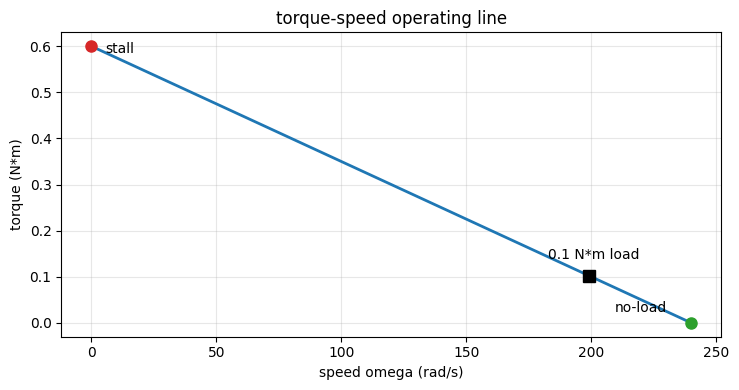

In [2]:
w, tau = dm.torque_speed_curve(V, R, Ke, Kt)
plt.figure(figsize=(7.5, 4))
plt.plot(w, tau, "C0", lw=2)
plt.plot(0, dm.stall_torque(V, R, Kt), "C3o", ms=8); plt.annotate("stall", (0, 0.6), textcoords="offset points", xytext=(10, -5))
plt.plot(V/Ke, 0, "C2o", ms=8); plt.annotate("no-load", (V/Ke, 0), textcoords="offset points", xytext=(-55, 8))
# a loaded operating point
ss = dm.steady_state(V, R, Ke, Kt, b, tau_load=0.1)
plt.plot(ss["speed"], ss["torque"], "ks", ms=8); plt.annotate("0.1 N*m load", (ss["speed"], ss["torque"]),
          textcoords="offset points", xytext=(-30, 12))
plt.xlabel("speed omega (rad/s)"); plt.ylabel("torque (N*m)")
plt.title("torque-speed operating line"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## §2 Turn-on transient — current inrush and speed ramp

Apply 12 V to the motor at rest. The fast electrical loop lets a large **inrush current** flow first
(limited only by $R$, since back-EMF is still zero), producing a torque spike that accelerates the
rotor; as $\omega$ rises the back-EMF $K_e\omega$ chokes the current back to its small running value.
Two time constants, electrical ($L/R$) and mechanical ($J/b$), in one second-order response.

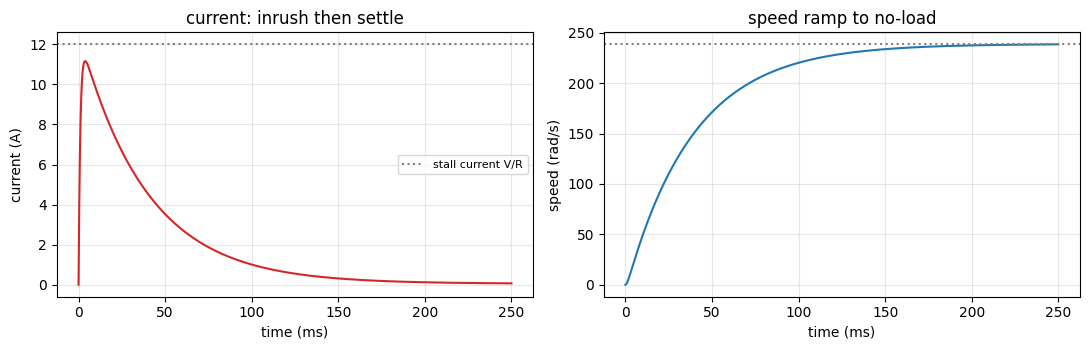

inrush peak 11.2 A; settles to 239 rad/s


In [3]:
out = dm.simulate(V, R, L, Ke, Kt, J, b, tau_load=0.0, dt=1e-5, t_end=0.25)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(out["t"]*1e3, out["i"], "C3"); ax[0].axhline(V/R, color="gray", ls=":", label="stall current V/R")
ax[0].set_xlabel("time (ms)"); ax[0].set_ylabel("current (A)"); ax[0].set_title("current: inrush then settle")
ax[0].legend(fontsize=8)
ax[1].plot(out["t"]*1e3, out["w"], "C0"); ax[1].axhline(dm.no_load_speed(V,R,Ke,Kt,b), color="gray", ls=":")
ax[1].set_xlabel("time (ms)"); ax[1].set_ylabel("speed (rad/s)"); ax[1].set_title("speed ramp to no-load")
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"inrush peak {out['i'].max():.1f} A; settles to {out['w'][-1]:.0f} rad/s")

## §3 Efficiency and the copper loss

Input power $V i$ splits into useful mechanical power $\tau\omega$ and losses — chiefly the
$i^2R$ **copper loss** in the windings. Efficiency peaks at a moderate load: too light and friction
dominates, too heavy (toward stall) and the copper loss runs away as the current climbs.

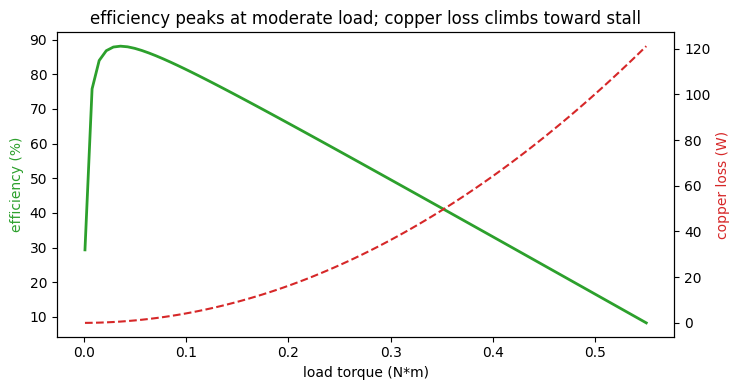

peak efficiency 88% at load 0.04 N*m


In [4]:
loads = np.linspace(0.001, 0.55, 80)
etas, coppers = [], []
for tl in loads:
    s = dm.steady_state(V, R, Ke, Kt, b, tau_load=tl)
    if s["current"] <= 0 or s["speed"] <= 0:
        etas.append(0); coppers.append(np.nan); continue
    # useful output = LOAD power tau_L * omega (not the friction part); in = V i
    eta = (tl * s["speed"]) / (V * s["current"]) * 100
    etas.append(eta); coppers.append(s["current"]**2 * R)

fig, ax1 = plt.subplots(figsize=(7.5, 4))
ax1.plot(loads, etas, "C2", lw=2, label="efficiency (%)"); ax1.set_xlabel("load torque (N*m)")
ax1.set_ylabel("efficiency (%)", color="C2")
ax2 = ax1.twinx(); ax2.plot(loads, coppers, "C3--", label="copper loss $i^2R$ (W)")
ax2.set_ylabel("copper loss (W)", color="C3")
ax1.set_title("efficiency peaks at moderate load; copper loss climbs toward stall")
fig.tight_layout(); plt.show()
print(f"peak efficiency {max(etas):.0f}% at load {loads[int(np.argmax(etas))]:.2f} N*m")

## §4 Where this lands — and why it ties the session together

A DC motor is a little anthology of the physics built this summer:

- **Torque is magnetostatics.** $\tau=K_t i$ is the Lorentz force on current in the field
  (`griffiths.magnetostatics`); the iron is `griffiths.magnetic_matter` concentrating the flux.
- **Back-EMF is Faraday.** $K_e\omega$ is the induced voltage of the spinning loop — the same
  $\mathbf E$/$\mathbf B$ coupling that completes Maxwell's equations.
- **The electrical loop is a circuit.** $V=Ri+L\,di/dt+\dots$ is an RL circuit with a speed-dependent
  source; `spice_sym` would stamp it directly.
- **Speed control is PID.** Close a loop that adjusts $V$ to hold a target $\omega$ against load and
  you have the controller from `pid_laser_control.ipynb` — and a leg joint that holds position. A
  **quadruped** is four of these motors plus the statics/torque bookkeeping from `statics.py` and the
  jerk-limited trajectories from `motion_profiles.py`.

Engine added this session: `dc_motor.py` (steady-state, torque-speed, RK4 transient, efficiency),
benchmarked in `scripts/smoke_dc_motor.py`.